In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

sys.path.append("../src/")
from devtools.use_devtools import parsers

In [2]:
base_dir = pathlib.Path("../data/master-servers/Mixed_WOrkloads")
vmstat = parsers.parse_all_vmstat(base_dir)
top = parsers.parse_all_top(base_dir)

In [3]:
vmstat_df = pd.DataFrame.from_dict(vmstat, orient="index")
vmstat_df["cpu"] = 100 - vmstat_df["id"]
vmstat_df

,r,b,swpd,free,buff,cache,si,so,bi,bo,in,cs,us,sy,id,wa,st,filename,cpu
1603749845,13,2,0,240352864,3384,2059012,0,0,3,3,22,54,0,2,97,0,0,../data/master-servers/Mixed_WOrkloads/Perflog...,3
1603749855,31,3,0,239693200,3384,2242252,0,0,238,21787,42281,96530,12,7,71,10,0,../data/master-servers/Mixed_WOrkloads/Perflog...,29
1603749865,3,6,0,239600024,3384,2273020,0,0,84,11347,39836,85193,12,7,79,2,0,../data/master-servers/Mixed_WOrkloads/Perflog...,21
1603749875,6,42,0,238661944,3384,2690860,0,0,697,37314,38425,60973,10,7,50,33,0,../data/master-servers/Mixed_WOrkloads/Perflog...,50
1603749885,0,18,0,238516316,3384,2749008,0,0,240,20911,26798,44827,6,6,43,45,0,../data/master-servers/Mixed_WOrkloads/Perflog...,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603786434,31,0,4616,5064776,272,233117872,0,0,519,61550,52523,58537,62,5,33,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,67
1603786444,31,0,4616,5102480,272,233139276,0,0,614,20073,44123,46140,57,4,39,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,61
1603786454,25,3,4616,5391112,272,233364148,0,0,141,14492,39274,42597,46,4,47,2,0,../data/master-servers/Mixed_WOrkloads/Perflog...,53
1603786464,23,0,4616,5428992,272,233263996,0,0,187,38369,39605,58581,39,5,55,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,45


In [4]:
filesets = [ [   '10k_files', 16,  10000, 99, 56],
                              [   '60k_files', 16,  60000, 99, 53],
                              [  '110k_files', 16,  110000, 99, 50],
                              [  '160k_files', 16,  160000, 99, 47],
                              [  '210k_files', 16,  210000, 99, 44],
                              [  '260k_files', 16,  260000, 99, 41],
                              [  '310k_files', 16,  310000, 99, 38],
                              [  '360k_files', 16,  360000, 99, 35],
                              [  '410k_files', 16,  410000, 99, 32],
                              [  '360k_files', 16,  460000, 99, 29],
                              [  '510k_files', 16,  510000, 99, 26],
                              [  '560k_files', 16,  560000, 99, 23],
                              [  '610k_files', 16,  610000, 99, 20],
                              [  '660k_files', 16,  660000, 99, 17],
                              [  '710k_files', 16,  710000, 99, 15],
                              [  '760k_files', 16,  760000, 99, 13],
                              [  '810k_files', 16,  810000, 99, 11],
                              [  '860k_files', 16,  860000, 99, 9],
                              [  '910k_files', 16,  910000, 99, 7],
                              [    '1m_files', 16,  1000000, 99, 5]]
total_files = sum(f[2] * f[4] for f in filesets)
weights = sum(f[4] for f in filesets)
files_per_proc = total_files / weights
files_per_proc

325061.295971979

In [5]:
top_df = pd.DataFrame.from_dict(top, orient="index").rename(columns={0: "procs", 1: "cpu"})
top_df["files"] = top_df["procs"] * 50_000
top_df

,filename,procs,cpu,files
1603749846,../data/master-servers/Mixed_WOrkloads/Perflog...,25,9.229167,1250000
1603749856,../data/master-servers/Mixed_WOrkloads/Perflog...,109,8.562500,5450000
1603749866,../data/master-servers/Mixed_WOrkloads/Perflog...,108,5.583333,5400000
1603749876,../data/master-servers/Mixed_WOrkloads/Perflog...,170,7.312500,8500000
1603749886,../data/master-servers/Mixed_WOrkloads/Perflog...,170,4.687500,8500000
...,...,...,...,...
1603786434,../data/master-servers/Mixed_WOrkloads/Perflog...,44,55.750000,2200000
1603786444,../data/master-servers/Mixed_WOrkloads/Perflog...,40,52.020833,2000000
1603786454,../data/master-servers/Mixed_WOrkloads/Perflog...,36,42.625000,1800000
1603786464,../data/master-servers/Mixed_WOrkloads/Perflog...,35,35.750000,1750000


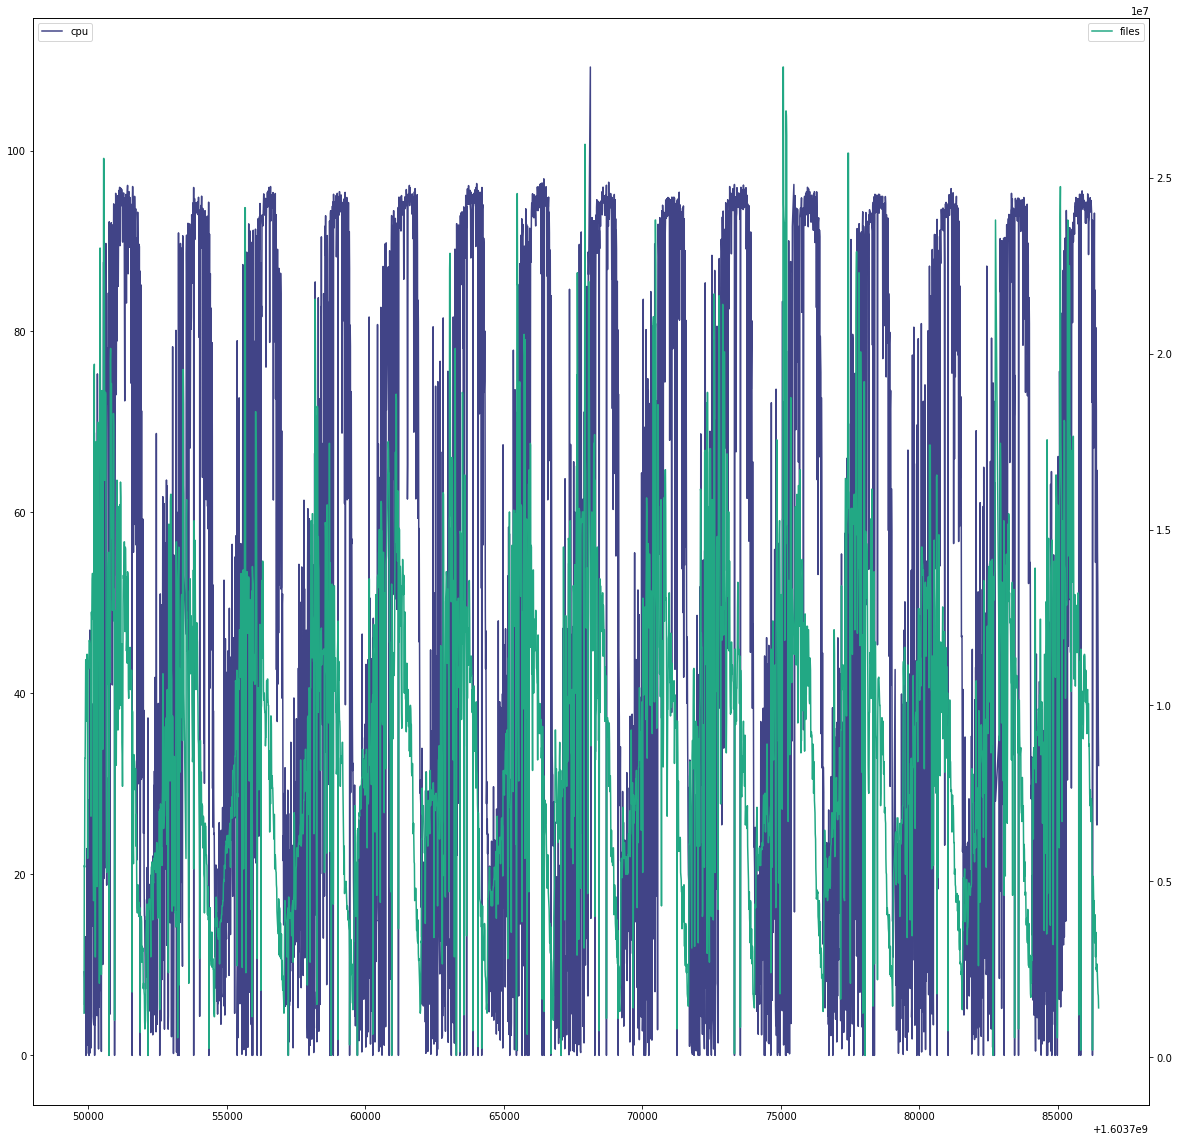

In [6]:
fig, ax = plt.subplots(figsize=(20, 20))
colors = sns.color_palette("viridis", 4)

ax.plot(top_df["cpu"], label="cpu", color=colors[0])
ax2 = ax.twinx()
ax2.plot(top_df["files"], label="files", color=colors[2])

ax.legend(loc="upper left")
ax2.legend(loc="upper right")

In [7]:
merged_df = pd.merge_asof(vmstat_df, top_df, left_index=True, right_index=True, tolerance=5)
merged_df.dropna()

,r,b,swpd,free,buff,cache,si,so,bi,bo,...,sy,id,wa,st,filename_x,cpu_x,filename_y,procs,cpu_y,files
1603750425,149,138,0,226357676,3384,10208260,0,0,904,31836,...,6,2,2,0,../data/master-servers/Mixed_WOrkloads/Perflog...,98,../data/master-servers/Mixed_WOrkloads/Perflog...,460.0,66.854167,23000000.0
1603750435,124,7,0,228546052,3384,10346400,0,0,131,30524,...,12,8,56,0,../data/master-servers/Mixed_WOrkloads/Perflog...,92,../data/master-servers/Mixed_WOrkloads/Perflog...,460.0,58.958333,23000000.0
1603750445,4,97,0,228263244,3384,10375064,0,0,675,31814,...,7,4,9,0,../data/master-servers/Mixed_WOrkloads/Perflog...,96,../data/master-servers/Mixed_WOrkloads/Perflog...,343.0,51.750000,17150000.0
1603750455,1,26,0,229564208,3384,10383844,0,0,1824,34981,...,10,21,56,0,../data/master-servers/Mixed_WOrkloads/Perflog...,79,../data/master-servers/Mixed_WOrkloads/Perflog...,328.0,30.854167,16400000.0
1603750465,0,18,0,229968884,3384,10502620,0,0,13,35926,...,10,67,22,0,../data/master-servers/Mixed_WOrkloads/Perflog...,33,../data/master-servers/Mixed_WOrkloads/Perflog...,129.0,11.354167,6450000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603786434,31,0,4616,5064776,272,233117872,0,0,519,61550,...,5,33,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,67,../data/master-servers/Mixed_WOrkloads/Perflog...,44.0,55.750000,2200000.0
1603786444,31,0,4616,5102480,272,233139276,0,0,614,20073,...,4,39,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,61,../data/master-servers/Mixed_WOrkloads/Perflog...,40.0,52.020833,2000000.0
1603786454,25,3,4616,5391112,272,233364148,0,0,141,14492,...,4,47,2,0,../data/master-servers/Mixed_WOrkloads/Perflog...,53,../data/master-servers/Mixed_WOrkloads/Perflog...,36.0,42.625000,1800000.0
1603786464,23,0,4616,5428992,272,233263996,0,0,187,38369,...,5,55,1,0,../data/master-servers/Mixed_WOrkloads/Perflog...,45,../data/master-servers/Mixed_WOrkloads/Perflog...,35.0,35.750000,1750000.0


In [8]:
model = smf.ols("cpu ~ files + files:files", data=top_df)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpu   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     266.1
Date:                Thu, 29 Oct 2020   Prob (F-statistic):           8.45e-58
Time:                        10:57:57   Log-Likelihood:                -18046.
No. Observations:                3652   AIC:                         3.610e+04
Df Residuals:                    3650   BIC:                         3.611e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.9928      1.268     26.009      0.000      30.506      35.480
files       2.001e-06   1.23e-07     16.313      0.000    1.76e-06    2.24e-06
==============================================================================
Omnibus:                    30289.634   Durbin-Watson:                   0.642
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              310.810
Skew:                          -0.006   Prob(JB):                     3.22e-68
Kurtosis:                       1.571   Cond. No.                     2.34e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.34e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
def key_extractor(row):
    parts = row["filename"].split("/")
    return parts[-2]
top_df["filekey"] = top_df.apply(key_extractor, axis=1)
vmstat_df["filekey"] = vmstat_df.apply(key_extractor, axis=1)
top_df["interval"] = top_df.index // 60
vmstat_df["interval"] = vmstat_df.index // 60

[Text(0.5, 0, 'Processes'), Text(0, 0.5, 'CPU Usage (%)')]

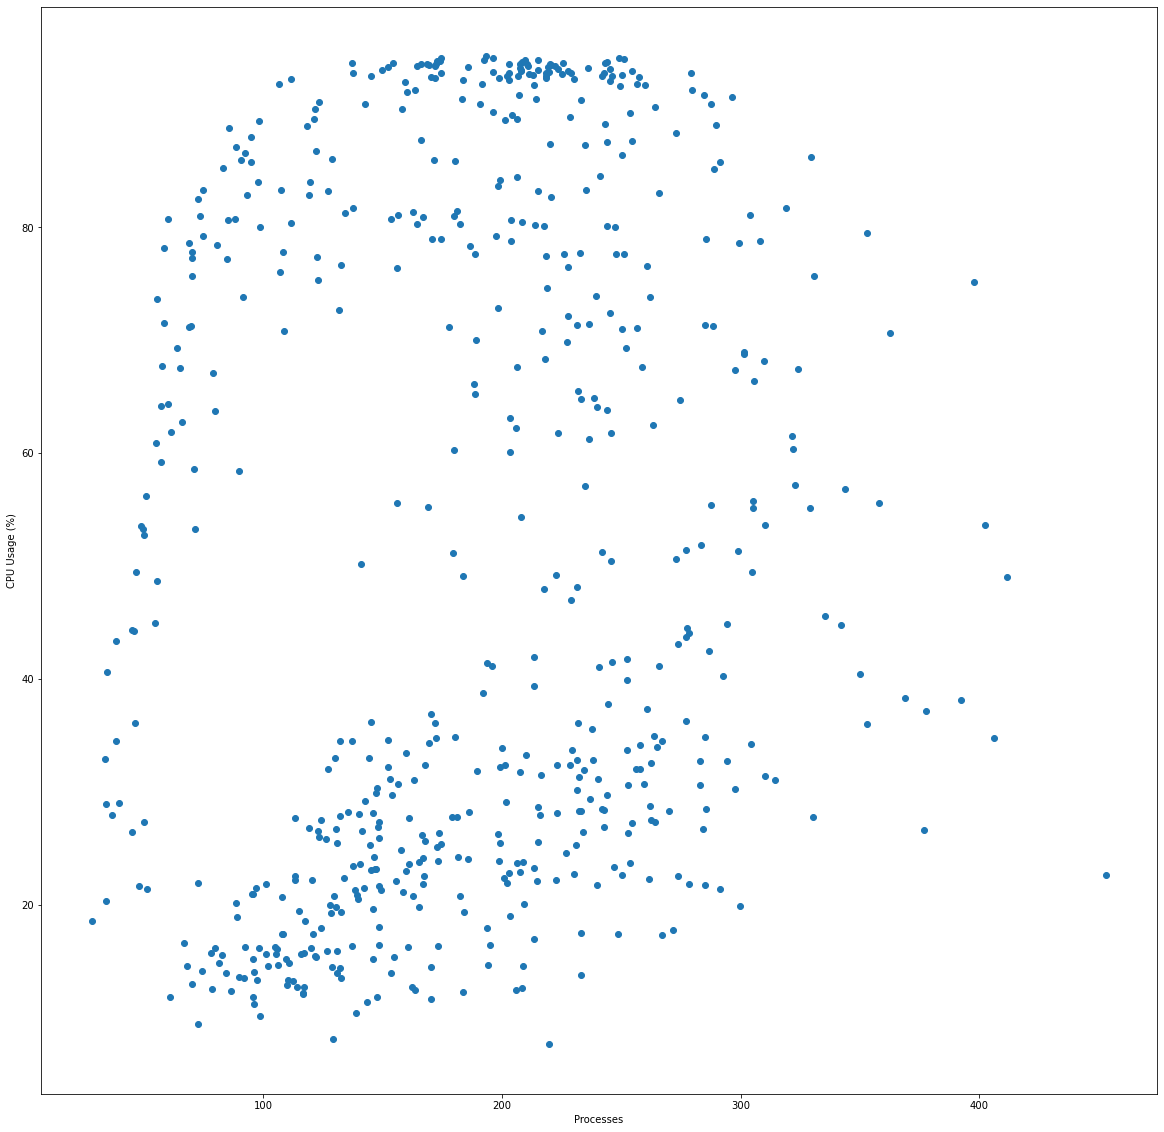

In [10]:
mean_procs = top_df.groupby("interval")["procs"].mean()
mean_cpu = top_df.groupby("interval")["cpu"].mean()

fig, ax = plt.subplots(figsize=(20, 20))
colors = sns.color_palette("viridis", 4)

ax.scatter(mean_procs, mean_cpu)
ax.set(xlabel="Processes", ylabel="CPU Usage (%)")

In [11]:
model = smf.ols("cpu ~ files ** 2", data=top_df)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpu   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     266.1
Date:                Thu, 29 Oct 2020   Prob (F-statistic):           8.45e-58
Time:                        10:57:57   Log-Likelihood:                -18046.
No. Observations:                3652   AIC:                         3.610e+04
Df Residuals:                    3650   BIC:                         3.611e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     32.9928      1.268     26.009      0.000      30.506      35.480
files       2.001e-06   1.23e-07     16.313      0.000    1.76e-06    2.24e-06
==============================================================================
Omnibus:                    30289.634   Durbin-Watson:                   0.642
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              310.810
Skew:                          -0.006   Prob(JB):                     3.22e-68
Kurtosis:                       1.571   Cond. No.                     2.34e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.34e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
result.predict(pd.DataFrame({"files": [0]}))

0    32.992847
dtype: float64